<a href="https://colab.research.google.com/github/Indra-sekhar/FUTURE_ML_01/blob/main/Sales_Demand_Forecasting_FUTURE_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales & Demand Forecasting for Businesses

## Business Problem
Businesses need accurate sales forecasts to:
- Plan inventory
- Manage staffing
- Optimize cash flow
- Avoid overstocking

This project builds a Machine Learning forecasting model using historical store sales data.

In [4]:
from google.colab import files
upload = files.upload()

Saving train.csv to train.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
train["date"] = pd.to_datetime(train["date"])

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [7]:
train["sales"].describe()

,sales
count,3.000888e+06
mean,3.577757e+02
std,1.101998e+03
min,0.000000e+00
25%,0.000000e+00
50%,1.100000e+01
75%,1.958473e+02
max,1.247170e+05


In [8]:
train["sales"].describe()

,sales
count,3.000888e+06
mean,3.577757e+02
std,1.101998e+03
min,0.000000e+00
25%,0.000000e+00
50%,1.100000e+01
75%,1.958473e+02
max,1.247170e+05


In [9]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


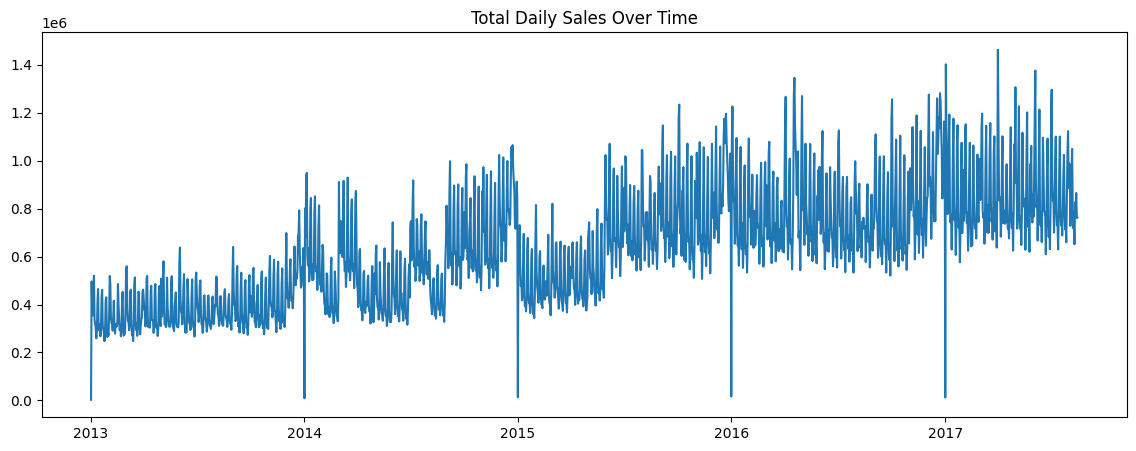

In [10]:
plt.figure(figsize=(14,5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales Over Time")
plt.show()

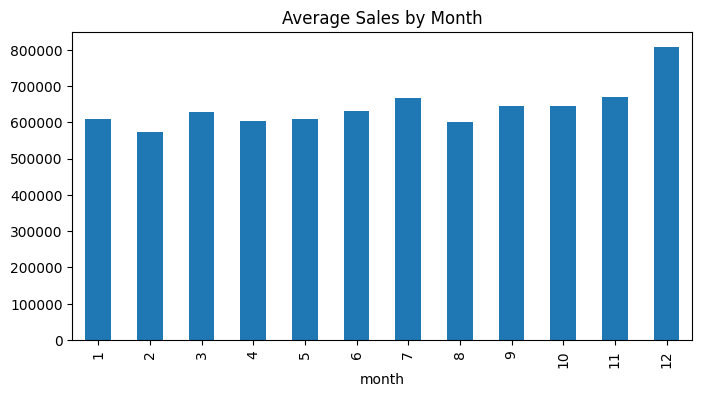

In [11]:
daily_sales["month"] = daily_sales["date"].dt.month
monthly = daily_sales.groupby("month")["sales"].mean()

monthly.plot(kind="bar", figsize=(8,4))
plt.title("Average Sales by Month")
plt.show()

In [12]:
df = daily_sales.copy()

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week

# Lag feature (previous day sales)
df["lag_1"] = df["sales"].shift(1)

# Rolling mean (7-day average)
df["rolling_7"] = df["sales"].rolling(7).mean()

df = df.dropna()
df.head()

,date,sales,month,day,dayofweek,weekofyear,lag_1,rolling_7
6,2013-01-07,336122.801066,1,7,0,2,519695.401088,363956.181220
7,2013-01-08,318347.777981,1,8,1,2,336122.801066,409075.632504
8,2013-01-09,302530.809018,1,9,2,2,318347.777981,381423.974086
9,2013-01-10,258982.003049,1,10,3,2,302530.809018,366784.084361
10,2013-01-11,289737.685085,1,11,4,2,258982.003049,357538.085502


In [13]:
train_size = int(len(df) * 0.8)

train_data = df[:train_size]
test_data = df[train_size:]

X_train = train_data.drop(["date", "sales"], axis=1)
y_train = train_data["sales"]

X_test = test_data.drop(["date", "sales"], axis=1)
y_test = test_data["sales"]

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 90445.68736287694
RMSE: 136338.63174153524


In [15]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAPE:", mape(y_test, predictions))

MAPE: 34.674219867332425


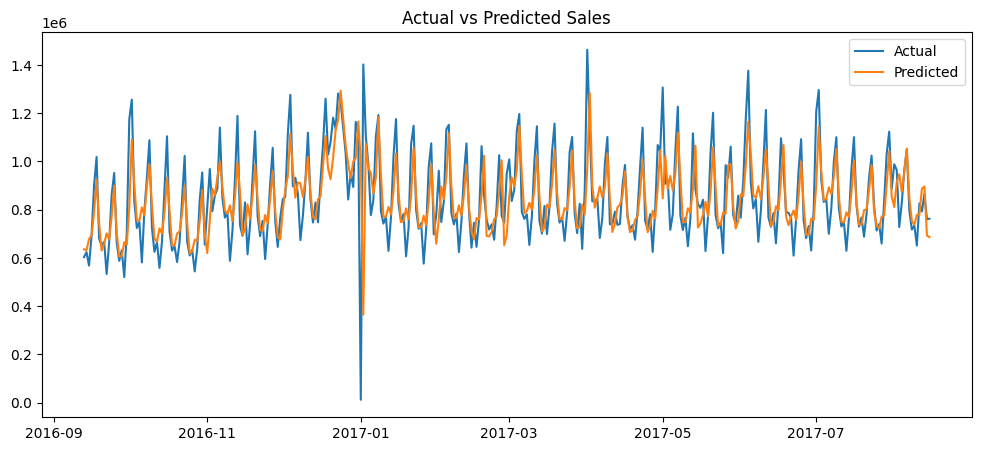

In [16]:
plt.figure(figsize=(12,5))
plt.plot(test_data["date"], y_test, label="Actual")
plt.plot(test_data["date"], predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [17]:
future_days = 30
last_data = df.tail(1)

future_predictions = []

for i in range(future_days):
    features = last_data.drop(["date", "sales"], axis=1)
    pred = model.predict(features)[0]
    future_predictions.append(pred)

future_predictions[:5]

[np.float64(686497.3082183887),
 np.float64(686497.3082183887),
 np.float64(686497.3082183887),
 np.float64(686497.3082183887),
 np.float64(686497.3082183887)]

## Business Interpretation

The forecast shows projected sales trends for the next 30 days.

If demand increases:
- The business should increase inventory
- Ensure adequate staffing
- Plan cash flow accordingly

If demand decreases:
- Reduce stock orders
- Avoid overproduction
- Optimize operational costs

This forecasting system helps business owners make proactive decisions instead of reactive ones.